# 📊 Análisis Fundamental Automatizado de Sector — SEC EDGAR Pipeline

**Versión:** 4.0 (DCF Probabilístico por Escenarios)  
**Fuente:** SEC EDGAR API (XBRL) + Yahoo Finance

### Escenarios DCF
| Escenario | Probabilidad | Lógica |
|-----------|-------------|--------|
| 🐻 Bear | 25% | Ciclo bajista, compresión de márgenes |
| 🐂 Base | 50% | Normalización del ciclo |
| 🚀 Bull | 25% | Expansión estructural por IA/data center |

In [1]:
# !pip install requests pandas numpy matplotlib seaborn scipy yfinance tqdm

## 1. Configuración

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import yfinance as yf
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid", font_scale=1.1)

# ============================================================
# CONFIGURACIÓN GLOBAL
# ============================================================
SEC_USER_AGENT = "MyCompany Analytics contact@mycompany.com"  # ⚠️ CAMBIAR
SECTOR_NAME    = "Semiconductors"

SECTOR_TICKERS = [
    "NVDA", "AMD", "INTC", "AVGO", "QCOM",
    "MU",   "AMAT", "LRCX", "KLAC", "TXN",
]

# Parámetros DCF
DCF_YEARS            = 5
TERMINAL_GROWTH_RATE = 0.025
N_SIMULATIONS        = 10_000

SCENARIO_WEIGHTS = {"bear": 0.25, "base": 0.50, "bull": 0.25}

SCENARIO_GROWTH_MULTIPLIERS = {
    "bear": {"mean_adj": -0.10, "std": 0.08},
    "base": {"mean_adj":  0.00, "std": 0.06},
    "bull": {"mean_adj": +0.12, "std": 0.07},
}

SCENARIO_WACC = {
    "bear": {"mean_adj": +0.015, "std": 0.015},
    "base": {"mean_adj":  0.000, "std": 0.015},
    "bull": {"mean_adj": -0.010, "std": 0.010},
}

SECTOR_FCF_FLOOR_GROWTH = -0.05
SECTOR_FCF_CEIL_GROWTH  =  0.60
SECTOR_MIN_WACC         =  0.07
SECTOR_MAX_WACC         =  0.18
NORMALIZATION_WEIGHTS   = {"last_year": 0.35, "3yr_avg": 0.40, "5yr_avg": 0.25}

SEC_TICKERS_URL       = "https://www.sec.gov/files/company_tickers.json"
SEC_COMPANY_FACTS_URL = "https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json"
HEADERS = {"User-Agent": SEC_USER_AGENT}

print(f"✅ Config cargada — {SECTOR_NAME} | {N_SIMULATIONS:,} sims/escenario")

✅ Config cargada — Semiconductors | 10,000 sims/escenario


## 2. Rate Limiter y Ticker → CIK

In [3]:
_last_call_times = []
_MAX_CALLS = 9
_PERIOD    = 1.0

def _rate_limited_get(url: str, headers: dict) -> requests.Response:
    """Rate limiter de ventana deslizante — máximo 9 req/s."""
    global _last_call_times
    now = time.monotonic()
    _last_call_times = [t for t in _last_call_times if now - t < _PERIOD]
    if len(_last_call_times) >= _MAX_CALLS:
        sleep_time = _PERIOD - (now - _last_call_times[0])
        if sleep_time > 0:
            time.sleep(sleep_time)
        _last_call_times = _last_call_times[1:]
    _last_call_times.append(time.monotonic())
    return requests.get(url, headers=headers, timeout=30)


def build_ticker_to_cik_map() -> dict:
    """Descarga el mapa completo Ticker → CIK desde la SEC."""
    try:
        r = _rate_limited_get(SEC_TICKERS_URL, HEADERS)
        r.raise_for_status()
        return {v.get("ticker", "").upper(): str(v.get("cik_str", "")).zfill(10)
                for v in r.json().values() if v.get("ticker")}
    except requests.exceptions.RequestException as e:
        print(f"❌ Error: {e}")
        return {}


TICKER_CIK_MAP = build_ticker_to_cik_map()
print(f"✅ {len(TICKER_CIK_MAP):,} tickers cargados")

ticker_cik_sector = {}
for ticker in SECTOR_TICKERS:
    cik = TICKER_CIK_MAP.get(ticker.upper())
    if cik:
        ticker_cik_sector[ticker] = cik
        print(f"  ✓ {ticker:6s} → CIK: {cik}")
    else:
        print(f"  ⚠️  {ticker} no encontrado")

✅ 10,386 tickers cargados
  ✓ NVDA   → CIK: 0001045810
  ✓ AMD    → CIK: 0000002488
  ✓ INTC   → CIK: 0000050863
  ✓ AVGO   → CIK: 0001730168
  ✓ QCOM   → CIK: 0000804328
  ✓ MU     → CIK: 0000723125
  ✓ AMAT   → CIK: 0000006951
  ✓ LRCX   → CIK: 0000707549
  ✓ KLAC   → CIK: 0000319201
  ✓ TXN    → CIK: 0000097476


## 3. Extracción XBRL

In [4]:
XBRL_CONCEPTS = {
    "revenue": [
        "Revenues",
        "RevenueFromContractWithCustomerExcludingAssessedTax",
        "SalesRevenueNet",
        "RevenueFromContractWithCustomerIncludingAssessedTax",
    ],
    "net_income":          ["NetIncomeLoss", "ProfitLoss"],
    "operating_cash_flow": ["NetCashProvidedByUsedInOperatingActivities"],
    "total_assets":        ["Assets"],
    "total_liabilities":   ["Liabilities"],
    "stockholders_equity": [
        "StockholdersEquity",
        "StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest",
    ],
    "current_assets":      ["AssetsCurrent"],
    "current_liabilities": ["LiabilitiesCurrent"],
    "capex":               ["PaymentsToAcquirePropertyPlantAndEquipment"],
    "ebit":                ["OperatingIncomeLoss"],
    "depreciation":        ["DepreciationDepletionAndAmortization", "DepreciationAndAmortization"],
}


def fetch_company_facts(cik: str) -> dict | None:
    try:
        r = _rate_limited_get(SEC_COMPANY_FACTS_URL.format(cik=cik), HEADERS)
        r.raise_for_status()
        return r.json()
    except requests.exceptions.RequestException as e:
        print(f"  ❌ CIK {cik}: {e}")
        return None


def extract_annual_series(facts: dict, aliases: list, years: int = 7) -> pd.Series:
    """Extrae serie anual de un concepto XBRL. 7 años para estimar volatilidad del FCF."""
    us_gaap = facts.get("facts", {}).get("us-gaap", {})
    for concept in aliases:
        if concept not in us_gaap:
            continue
        try:
            usd_data = us_gaap[concept].get("units", {}).get("USD", [])
            if not usd_data:
                continue
            df = pd.DataFrame(usd_data)
            mask = df["form"].isin(["10-K", "10-K/A"]) if "form" in df.columns else pd.Series([True]*len(df))
            df = df[mask].copy()
            if df.empty:
                continue
            df["end"]         = pd.to_datetime(df["end"])
            df["fiscal_year"] = df["end"].dt.year
            df = df.sort_values("end").drop_duplicates(subset="fiscal_year", keep="last")
            return df.set_index("fiscal_year")["val"].sort_index().tail(years)
        except (KeyError, TypeError, ValueError):
            continue
    return pd.Series(dtype=float)


def extract_company_financials(ticker: str, cik: str) -> dict:
    facts = fetch_company_facts(cik)
    if facts is None:
        return {"ticker": ticker, "error": "No company facts"}
    fin = {"ticker": ticker, "cik": cik}
    for metric, aliases in XBRL_CONCEPTS.items():
        try:
            fin[metric] = extract_annual_series(facts, aliases)
        except Exception as e:
            fin[metric] = pd.Series(dtype=float)
    return fin


sector_raw_data = {}
for ticker, cik in tqdm(ticker_cik_sector.items(), desc="Descargando SEC EDGAR"):
    print(f"\n🔍 {ticker} (CIK: {cik})")
    sector_raw_data[ticker] = extract_company_financials(ticker, cik)
    rev = sector_raw_data[ticker].get("revenue", pd.Series())
    if not rev.empty:
        print(f"   Revenue más reciente: ${rev.iloc[-1]/1e9:.2f}B")

print(f"\n✅ Datos descargados: {len(sector_raw_data)} empresas")

Descargando SEC EDGAR:   0%|          | 0/10 [00:00<?, ?it/s]


🔍 NVDA (CIK: 0001045810)


Descargando SEC EDGAR:  10%|█         | 1/10 [00:01<00:09,  1.03s/it]

   Revenue más reciente: $130.50B

🔍 AMD (CIK: 0000002488)


Descargando SEC EDGAR:  20%|██        | 2/10 [00:02<00:08,  1.12s/it]

...

   Revenue más reciente: $3.24B

🔍 KLAC (CIK: 0000319201)


Descargando SEC EDGAR:  90%|█████████ | 9/10 [00:07<00:00,  1.38it/s]

   Revenue más reciente: $12.16B

🔍 TXN (CIK: 0000097476)


Descargando SEC EDGAR: 100%|██████████| 10/10 [00:07<00:00,  1.29it/s]

   Revenue más reciente: $17.68B

✅ Datos descargados: 10 empresas


## 4. Ratios Financieros

In [5]:
def safe_div(a, b):
    return a / b.replace(0, np.nan)

def align_series(s1, s2):
    idx = s1.index.intersection(s2.index)
    return s1.loc[idx], s2.loc[idx]


def calculate_ratios(fin: dict) -> pd.DataFrame:
    """Calcula ratios financieros vectorizados para una empresa."""
    ticker  = fin.get("ticker", "UNKNOWN")
    revenue = fin.get("revenue",              pd.Series(dtype=float))
    ni      = fin.get("net_income",           pd.Series(dtype=float))
    assets  = fin.get("total_assets",         pd.Series(dtype=float))
    liab    = fin.get("total_liabilities",    pd.Series(dtype=float))
    equity  = fin.get("stockholders_equity",  pd.Series(dtype=float))
    ca      = fin.get("current_assets",       pd.Series(dtype=float))
    cl      = fin.get("current_liabilities",  pd.Series(dtype=float))
    ocf     = fin.get("operating_cash_flow",  pd.Series(dtype=float))
    capex   = fin.get("capex",                pd.Series(dtype=float))
    ebit    = fin.get("ebit",                 pd.Series(dtype=float))
    depr    = fin.get("depreciation",         pd.Series(dtype=float))

    if revenue.empty and assets.empty:
        return pd.DataFrame()

    base_idx = revenue.index if not revenue.empty else assets.index
    df = pd.DataFrame(index=base_idx)
    df.index.name = "fiscal_year"
    df["ticker"]  = ticker

    df["revenue_bn"]         = revenue.reindex(base_idx) / 1e9
    df["net_income_bn"]      = ni.reindex(base_idx) / 1e9
    df["total_assets_bn"]    = assets.reindex(base_idx) / 1e9
    df["revenue_growth_pct"] = revenue.pct_change().reindex(base_idx) * 100

    ni_a, eq_a = align_series(ni, equity)
    df["roe_pct"] = safe_div(ni_a, eq_a).reindex(base_idx) * 100

    ni_b, as_a = align_series(ni, assets)
    df["roa_pct"] = safe_div(ni_b, as_a).reindex(base_idx) * 100

    ni_c, rv_a = align_series(ni, revenue)
    df["net_margin_pct"] = safe_div(ni_c, rv_a).reindex(base_idx) * 100

    lb_a, eq_b = align_series(liab, equity)
    df["debt_to_equity"] = safe_div(lb_a, eq_b).reindex(base_idx)

    ca_a, cl_a = align_series(ca, cl)
    df["current_ratio"] = safe_div(ca_a, cl_a).reindex(base_idx)

    rv_b, as_b = align_series(revenue, assets)
    df["asset_turnover"] = safe_div(rv_b, as_b).reindex(base_idx)

    if not ocf.empty and not capex.empty:
        oc_a, cx_a = align_series(ocf, capex)
        fcf = oc_a - cx_a.abs()
    elif not ocf.empty:
        fcf = ocf * 0.85
    else:
        fcf = pd.Series(dtype=float)
    df["fcf_bn"] = fcf.reindex(base_idx) / 1e9

    if not ebit.empty and not depr.empty:
        eb_a, dp_a = align_series(ebit, depr)
        ebitda = eb_a + dp_a
        eb_b, rv_c = align_series(ebitda, revenue)
        df["ebitda_margin_pct"] = safe_div(eb_b, rv_c).reindex(base_idx) * 100
    else:
        df["ebitda_margin_pct"] = np.nan

    return df.reset_index()


sector_ratios_list = []
for ticker, fin in sector_raw_data.items():
    if "error" in fin:
        print(f"⚠️  {ticker}: {fin['error']}")
        continue
    try:
        df_r = calculate_ratios(fin)
        if not df_r.empty:
            sector_ratios_list.append(df_r)
    except Exception as e:
        print(f"❌ {ticker}: {e}")

sector_df = pd.concat(sector_ratios_list, ignore_index=True)
latest_year_df = (
    sector_df.sort_values("fiscal_year")
    .groupby("ticker").last().reset_index()
)

print(f"✅ sector_df: {sector_df.shape}")
latest_year_df[["ticker","fiscal_year","revenue_bn","net_margin_pct",
                "roe_pct","debt_to_equity","current_ratio","fcf_bn"]].round(2)

✅ sector_df: (55, 14)


,ticker,fiscal_year,revenue_bn,net_margin_pct,roe_pct,debt_to_equity,current_ratio,fcf_bn
0,AMAT,2019,3.75,18.59,8.50,1.32,2.30,2.81
1,AMD,2025,34.64,12.51,6.88,NaN,2.85,6.74
2,AVGO,2018,5.44,20.48,4.18,NaN,NaN,NaN
3,INTC,2025,52.85,-0.51,-0.23,NaN,2.02,-4.95
4,KLAC,2025,12.16,33.41,86.56,2.42,2.62,3.75
5,LRCX,2011,3.24,NaN,NaN,NaN,NaN,NaN
6,MU,2018,8.44,NaN,NaN,NaN,NaN,NaN
7,NVDA,2025,130.50,55.85,91.87,0.41,4.44,NaN
8,QCOM,2025,44.28,12.51,89.35,5.71,2.82,11.91
9,TXN,2025,17.68,28.28,30.73,1.13,4.35,2.60


## 5. DCF Probabilístico — Familias de Escenarios

**FCF normalizado:** `35% × último año + 40% × promedio 3 años + 25% × promedio 5 años`  
**Crecimiento base:** combinación de CAGR revenue (40%), mediana YoY FCF (35%), tendencia de márgenes (25%)  
**WACC:** CAPM con ajuste de Vasicek (`beta_adj = 0.67 × beta + 0.33 × 1.0`)  
**Total paths:** 3 escenarios × 10.000 simulaciones = 30.000 por empresa

In [6]:
def compute_normalized_fcf(fcf_series: pd.Series) -> tuple[float, float]:
    """FCF normalizado ponderado + volatilidad histórica.
    
    Combina último año, promedio 3 años y promedio 5 años para suavizar
    el ciclo de CapEx sin ignorar el estado actual.
    Solo usa años positivos para la base y todos para la volatilidad.
    """
    fcf = fcf_series.dropna()
    if fcf.empty:
        return 1e9, 0.30

    last_yr = float(fcf.iloc[-1]) if fcf.iloc[-1] > 0 else float(fcf[fcf > 0].iloc[-1]) if (fcf > 0).any() else float(fcf.abs().mean())
    avg_3yr = float(fcf.iloc[-3:].clip(lower=0).mean()) if len(fcf) >= 3 else last_yr
    avg_5yr = float(fcf.iloc[-5:].clip(lower=0).mean()) if len(fcf) >= 5 else avg_3yr

    normalized = (
        NORMALIZATION_WEIGHTS["last_year"] * last_yr +
        NORMALIZATION_WEIGHTS["3yr_avg"]   * avg_3yr +
        NORMALIZATION_WEIGHTS["5yr_avg"]   * avg_5yr
    )
    normalized = max(normalized, 5e7)

    if len(fcf) >= 3:
        fcf_returns = fcf.pct_change().dropna().replace([np.inf, -np.inf], np.nan).dropna()
        vol = float(np.clip(fcf_returns.std(), 0.05, 0.60))
    else:
        vol = 0.25

    return normalized, vol


def compute_sector_adjusted_growth(
    fcf_series: pd.Series,
    revenue_series: pd.Series,
    margin_series: pd.Series,
) -> float:
    """Tasa de crecimiento base multi-señal ajustada al sector.
    
    Combina: CAGR Revenue (40%) + Mediana YoY FCF (35%) + Tendencia márgenes (25%).
    Floor sectorial de -5%: semiconductores no declina estructuralmente.
    """
    rev = revenue_series.dropna()
    if len(rev) >= 3 and rev.iloc[0] > 0 and rev.iloc[-1] > 0:
        rev_cagr = float(np.clip((rev.iloc[-1] / rev.iloc[0]) ** (1 / (len(rev)-1)) - 1, -0.15, 0.50))
    else:
        rev_cagr = 0.05

    margin = margin_series.dropna()
    if len(margin) >= 3:
        slope, _ = np.polyfit(np.arange(len(margin)), margin.values, 1)
        margin_contrib = float(np.clip(slope * 2.0, -0.10, 0.10))
    else:
        margin_contrib = 0.0

    fcf = fcf_series.dropna()
    if len(fcf) >= 3:
        fcf_yoy = fcf.pct_change().dropna().replace([np.inf, -np.inf], np.nan).dropna()
        fcf_med_growth = float(np.clip(fcf_yoy.median(), -0.20, 0.50))
    else:
        fcf_med_growth = rev_cagr

    base_growth = 0.40 * rev_cagr + 0.35 * fcf_med_growth + 0.25 * margin_contrib
    return float(np.clip(base_growth, SECTOR_FCF_FLOOR_GROWTH, SECTOR_FCF_CEIL_GROWTH))


def estimate_wacc_probabilistic(ticker: str) -> float:
    """WACC via CAPM con ajuste de Vasicek (atrae beta extremo hacia 1.0)."""
    try:
        info     = yf.Ticker(ticker).info
        raw_beta = float(info.get("beta", 1.3) or 1.3)
        beta_adj = float(np.clip(0.67 * raw_beta + 0.33 * 1.0, 0.5, 2.5))
        ke       = 0.045 + beta_adj * 0.052
        return float(np.clip(ke, SECTOR_MIN_WACC, SECTOR_MAX_WACC))
    except Exception:
        return 0.10


def simulate_scenario(
    base_fcf: float, base_growth: float, fcf_vol: float,
    wacc_base: float, scenario: str,
    n_sim: int = N_SIMULATIONS, years: int = DCF_YEARS,
    terminal_g: float = TERMINAL_GROWTH_RATE,
) -> np.ndarray:
    """Simula N paths DCF para un escenario. Completamente vectorizado en NumPy.
    
    Cada path samplea independientemente la tasa de crecimiento FCF y el WACC
    según la distribución del escenario (Bear/Base/Bull).
    """
    sc_g = SCENARIO_GROWTH_MULTIPLIERS[scenario]
    sc_w = SCENARIO_WACC[scenario]

    growth_mean = np.clip(base_growth + sc_g["mean_adj"], SECTOR_FCF_FLOOR_GROWTH, SECTOR_FCF_CEIL_GROWTH)
    growth_std  = np.clip(np.sqrt(fcf_vol**2 * 0.5 + sc_g["std"]**2), 0.03, 0.40)

    g_samples = np.clip(
        np.random.normal(growth_mean, growth_std, n_sim),
        SECTOR_FCF_FLOOR_GROWTH - 0.10, SECTOR_FCF_CEIL_GROWTH
    )
    w_samples = np.clip(
        np.random.normal(np.clip(wacc_base + sc_w["mean_adj"], SECTOR_MIN_WACC, SECTOR_MAX_WACC),
                         sc_w["std"], n_sim),
        SECTOR_MIN_WACC, SECTOR_MAX_WACC
    )

    t            = np.arange(1, years + 1)
    fcf_proj     = base_fcf * (1 + g_samples[:, np.newaxis]) ** t[np.newaxis, :]
    disc_factors = 1.0 / (1 + w_samples[:, np.newaxis]) ** t[np.newaxis, :]
    pv_fcf       = np.sum(fcf_proj * disc_factors, axis=1)

    fcf_n = fcf_proj[:, -1]
    tv    = np.where(
        w_samples > terminal_g,
        fcf_n * (1 + terminal_g) / (w_samples - terminal_g),
        fcf_n * (1 + terminal_g) / 0.005
    )
    intrinsic = pv_fcf + tv * disc_factors[:, -1]
    intrinsic = intrinsic[intrinsic > 0]
    if len(intrinsic) > 100:
        intrinsic = intrinsic[np.abs(stats.zscore(intrinsic)) < 4]
    return intrinsic


def run_probabilistic_dcf(ticker: str, financials: dict) -> dict:
    """DCF probabilístico completo: 3 escenarios × N_SIMULATIONS paths = 30.000 por empresa."""
    np.random.seed(42)

    ocf   = financials.get("operating_cash_flow", pd.Series(dtype=float))
    capex = financials.get("capex",               pd.Series(dtype=float))
    rev   = financials.get("revenue",             pd.Series(dtype=float))
    ni    = financials.get("net_income",          pd.Series(dtype=float))

    if not ocf.empty and not capex.empty:
        oc_a, cx_a = align_series(ocf, capex)
        fcf_series = oc_a - cx_a.abs()
    elif not ocf.empty:
        fcf_series = ocf * 0.85
    else:
        return {"ticker": ticker, "error": "Sin datos de FCF"}

    if not ni.empty and not rev.empty:
        ni_a, rv_a = align_series(ni, rev)
        margin_series = safe_div(ni_a, rv_a)
    else:
        margin_series = pd.Series(dtype=float)

    base_fcf, fcf_vol = compute_normalized_fcf(fcf_series)
    base_growth       = compute_sector_adjusted_growth(fcf_series, rev, margin_series)
    wacc_base         = estimate_wacc_probabilistic(ticker)

    scenario_distributions = {}
    all_values = []

    for scenario, weight in SCENARIO_WEIGHTS.items():
        dist   = simulate_scenario(base_fcf, base_growth, fcf_vol, wacc_base, scenario)
        scenario_distributions[scenario] = dist
        n_sample = int(len(dist) * weight)
        if n_sample > 0:
            all_values.append(np.random.choice(dist, size=n_sample, replace=False))

    if not all_values:
        return {"ticker": ticker, "error": "Sin simulaciones válidas"}

    combined = np.concatenate(all_values)

    try:
        info       = yf.Ticker(ticker).info
        market_cap = info.get("marketCap", None)
        cur_price  = info.get("currentPrice", info.get("regularMarketPrice", None))
    except Exception:
        market_cap, cur_price = None, None

    median_iv = float(np.median(combined))

    result = {
        "ticker":            ticker,
        "base_fcf_bn":       base_fcf / 1e9,
        "normalized_fcf_bn": base_fcf / 1e9,
        "fcf_vol":           fcf_vol,
        "base_growth_pct":   base_growth * 100,
        "wacc_base_pct":     wacc_base * 100,
        "dcf_p10_bn":        float(np.percentile(combined, 10))  / 1e9,
        "dcf_p25_bn":        float(np.percentile(combined, 25))  / 1e9,
        "dcf_median_bn":     median_iv / 1e9,
        "dcf_mean_bn":       float(np.mean(combined))            / 1e9,
        "dcf_p75_bn":        float(np.percentile(combined, 75))  / 1e9,
        "dcf_p90_bn":        float(np.percentile(combined, 90))  / 1e9,
        "bear_median_bn":    float(np.median(scenario_distributions["bear"])) / 1e9,
        "base_median_bn":    float(np.median(scenario_distributions["base"])) / 1e9,
        "bull_median_bn":    float(np.median(scenario_distributions["bull"])) / 1e9,
        "market_cap_bn":     market_cap / 1e9 if market_cap else None,
        "current_price":     cur_price,
        "dist_combined":     combined,
        "dist_bear":         scenario_distributions["bear"],
        "dist_base":         scenario_distributions["base"],
        "dist_bull":         scenario_distributions["bull"],
    }

    if market_cap and median_iv > 0:
        result["upside_pct"]        = (median_iv / market_cap - 1) * 100
        result["upside_bear_pct"]   = (result["bear_median_bn"] * 1e9 / market_cap - 1) * 100
        result["upside_bull_pct"]   = (result["bull_median_bn"] * 1e9 / market_cap - 1) * 100
        result["prob_above_mktcap"] = float(np.mean(combined > market_cap)) * 100

    return result


print("✅ Módulo DCF Probabilístico definido — ejecutando...\n")

dcf_results = {}
for ticker, financials in tqdm(sector_raw_data.items(), desc="DCF Probabilístico"):
    if "error" in financials:
        continue
    try:
        result = run_probabilistic_dcf(ticker, financials)
        dcf_results[ticker] = result
        if "error" not in result:
            prob   = result.get("prob_above_mktcap", float("nan"))
            upside = result.get("upside_pct", float("nan"))
            print(f"  ✓ {ticker:6s} | FCF: ${result['base_fcf_bn']:.1f}B "
                  f"| Growth: {result['base_growth_pct']:.1f}% "
                  f"| WACC: {result['wacc_base_pct']:.1f}% "
                  f"| Median IV: ${result['dcf_median_bn']:.0f}B "
                  f"| Mkt: ${result.get('market_cap_bn',0) or 0:.0f}B "
                  f"| Upside: {upside:.1f}% | P(IV>Mkt): {prob:.1f}%")
        else:
            print(f"  ❌ {ticker}: {result['error']}")
    except Exception as e:
        print(f"  ❌ {ticker}: {e}")
        dcf_results[ticker] = {"ticker": ticker, "error": str(e)}

NON_ARRAY_KEYS = [
    "ticker", "base_fcf_bn", "normalized_fcf_bn", "fcf_vol",
    "base_growth_pct", "wacc_base_pct",
    "dcf_p10_bn", "dcf_p25_bn", "dcf_median_bn", "dcf_mean_bn",
    "dcf_p75_bn", "dcf_p90_bn",
    "bear_median_bn", "base_median_bn", "bull_median_bn",
    "market_cap_bn", "current_price",
    "upside_pct", "upside_bear_pct", "upside_bull_pct", "prob_above_mktcap",
]

dcf_df = pd.DataFrame([
    {k: r.get(k) for k in NON_ARRAY_KEYS}
    for r in dcf_results.values() if "error" not in r
])

print(f"\n✅ DCF completado: {len(dcf_df)} empresas")
dcf_df[["ticker","base_growth_pct","wacc_base_pct",
        "bear_median_bn","base_median_bn","bull_median_bn",
        "market_cap_bn","upside_pct","prob_above_mktcap"]].round(1)

✅ Módulo DCF Probabilístico definido — ejecutando...



DCF Probabilístico:  10%|█         | 1/10 [00:03<00:27,  3.07s/it]

  ✓ NVDA   | FCF: $1.0B | Growth: 40.0% | WACC: 14.3% | Median IV: $34B | Mkt: $4622B | Upside: -99.3% | P(IV>Mkt): 0.0%


DCF Probabilístico:  20%|██        | 2/10 [00:04<00:17,  2.23s/it]

  ✓ AMD    | FCF: $4.6B | Growth: 36.8% | WACC: 13.0% | Median IV: $159B | Mkt: $326B | Upside: -51.4% | P(IV>Mkt): 18.7%


...

DCF Probabilístico:  90%|█████████ | 9/10 [00:16<00:01,  1.72s/it]

  ✓ KLAC   | FCF: $3.4B | Growth: 25.2% | WACC: 11.3% | Median IV: $99B | Mkt: $197B | Upside: -49.9% | P(IV>Mkt): 18.6%


DCF Probabilístico: 100%|██████████| 10/10 [00:18<00:00,  1.81s/it]

  ✓ TXN    | FCF: $2.5B | Growth: 13.2% | WACC: 9.7% | Median IV: $57B | Mkt: $200B | Upside: -71.5% | P(IV>Mkt): 17.0%

✅ DCF completado: 10 empresas


,ticker,base_growth_pct,wacc_base_pct,bear_median_bn,base_median_bn,bull_median_bn,market_cap_bn,upside_pct,prob_above_mktcap
0,NVDA,40.0,14.3,21.0,33.6,53.8,4621.5,-99.3,0.0
1,AMD,36.8,13.0,95.5,155.6,261.7,326.3,-51.4,18.7
2,INTC,-5.0,11.0,31.8,37.7,71.6,220.3,-81.1,14.1
3,AVGO,3.0,10.5,178.1,297.2,554.6,1577.2,-80.6,0.1
4,QCOM,18.9,10.5,150.0,266.1,484.3,152.6,78.0,68.9
5,MU,11.3,11.5,11.0,19.3,35.3,481.9,-95.9,0.0
6,AMAT,-2.7,12.1,42.1,53.3,99.8,297.9,-80.5,3.8
7,LRCX,23.9,12.4,64.3,108.5,188.5,307.6,-63.1,16.4
8,KLAC,25.2,11.3,55.5,96.0,167.4,196.6,-49.9,18.6
9,TXN,13.2,9.7,30.3,55.8,102.8,199.7,-71.5,17.0


## 6. Visualizaciones

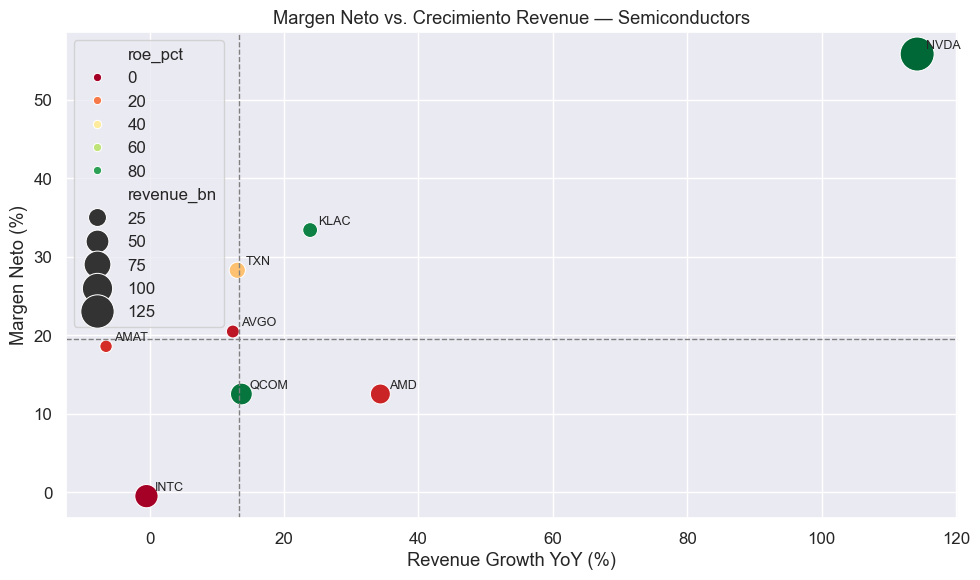

In [7]:
# ── 6.1 Scatter: Margen Neto vs. Crecimiento Revenue ─────────────────────────
df_plot = latest_year_df.dropna(subset=["net_margin_pct", "revenue_growth_pct"])

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_plot, x="revenue_growth_pct", y="net_margin_pct",
    size="revenue_bn", hue="roe_pct", palette="RdYlGn",
    sizes=(80, 600), ax=ax
)
for _, row in df_plot.iterrows():
    ax.annotate(row["ticker"],
                (row["revenue_growth_pct"], row["net_margin_pct"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.axhline(df_plot["net_margin_pct"].median(), color="gray", linestyle="--", linewidth=1)
ax.axvline(df_plot["revenue_growth_pct"].median(), color="gray", linestyle="--", linewidth=1)
ax.set_title(f"Margen Neto vs. Crecimiento Revenue — {SECTOR_NAME}")
ax.set_xlabel("Revenue Growth YoY (%)")
ax.set_ylabel("Margen Neto (%)")
plt.tight_layout()
plt.show()

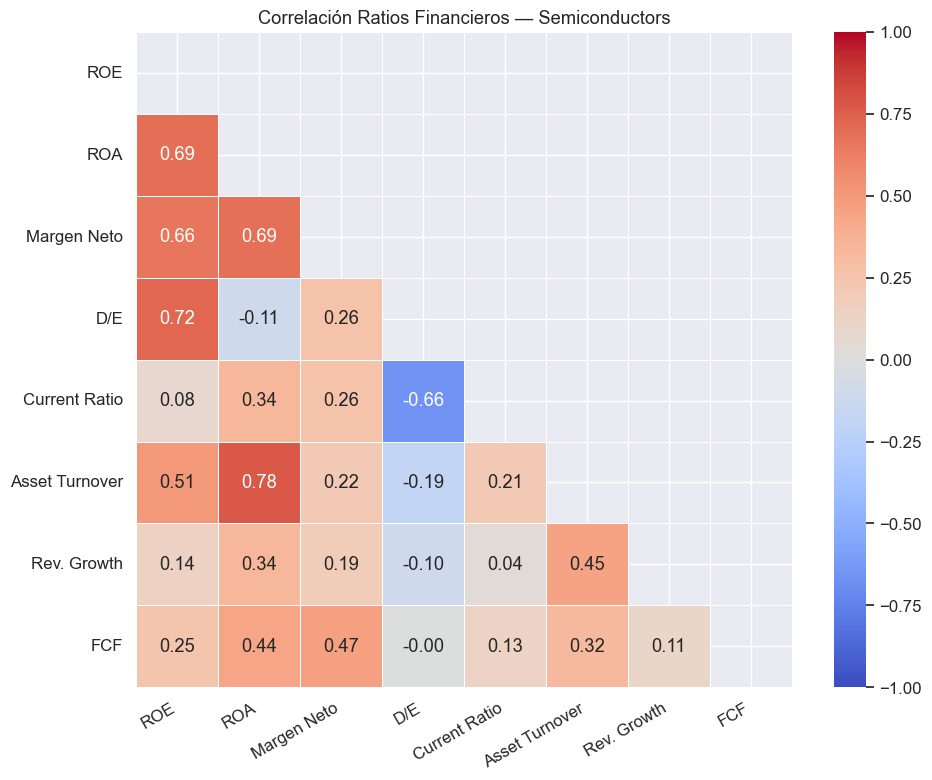

In [8]:
# ── 6.2 Heatmap de correlación ────────────────────────────────────────────────
ratio_cols = ["roe_pct","roa_pct","net_margin_pct","debt_to_equity",
              "current_ratio","asset_turnover","revenue_growth_pct","fcf_bn"]
labels     = ["ROE","ROA","Margen Neto","D/E",
              "Current Ratio","Asset Turnover","Rev. Growth","FCF"]

df_corr = sector_df[ratio_cols].dropna(thresh=4).copy()
for col in ratio_cols:
    q1, q99 = df_corr[col].quantile([0.01, 0.99])
    df_corr[col] = df_corr[col].clip(q1, q99)

corr = df_corr.corr()
corr.columns = labels
corr.index   = labels
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax)
ax.set_title(f"Correlación Ratios Financieros — {SECTOR_NAME}")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

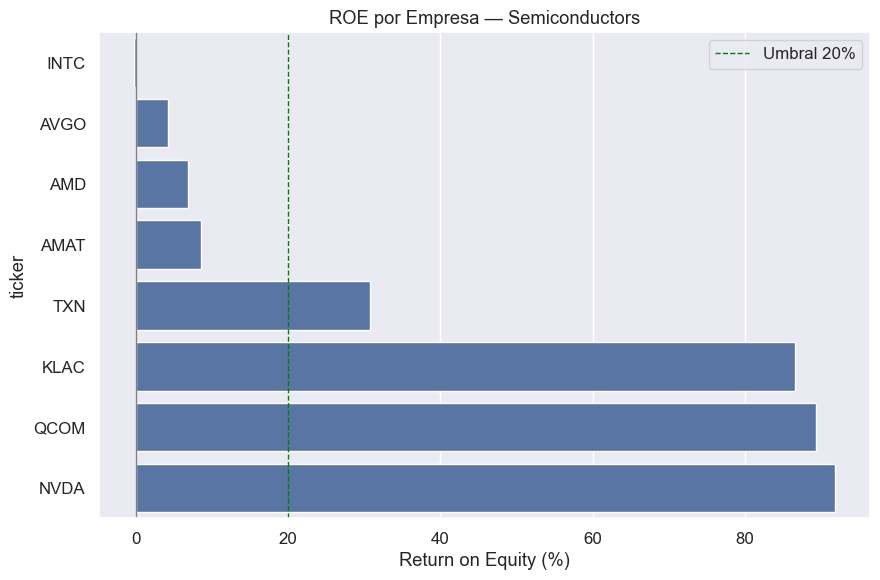

In [9]:
# ── 6.3 ROE ranking ───────────────────────────────────────────────────────────
df_roe = latest_year_df.dropna(subset=["roe_pct"]).sort_values("roe_pct")

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=df_roe, x="roe_pct", y="ticker", orient="h", ax=ax)
ax.axvline(0,  color="gray", linewidth=1)
ax.axvline(20, color="green", linewidth=1, linestyle="--", label="Umbral 20%")
ax.set_title(f"ROE por Empresa — {SECTOR_NAME}")
ax.set_xlabel("Return on Equity (%)")
ax.legend()
plt.tight_layout()
plt.show()

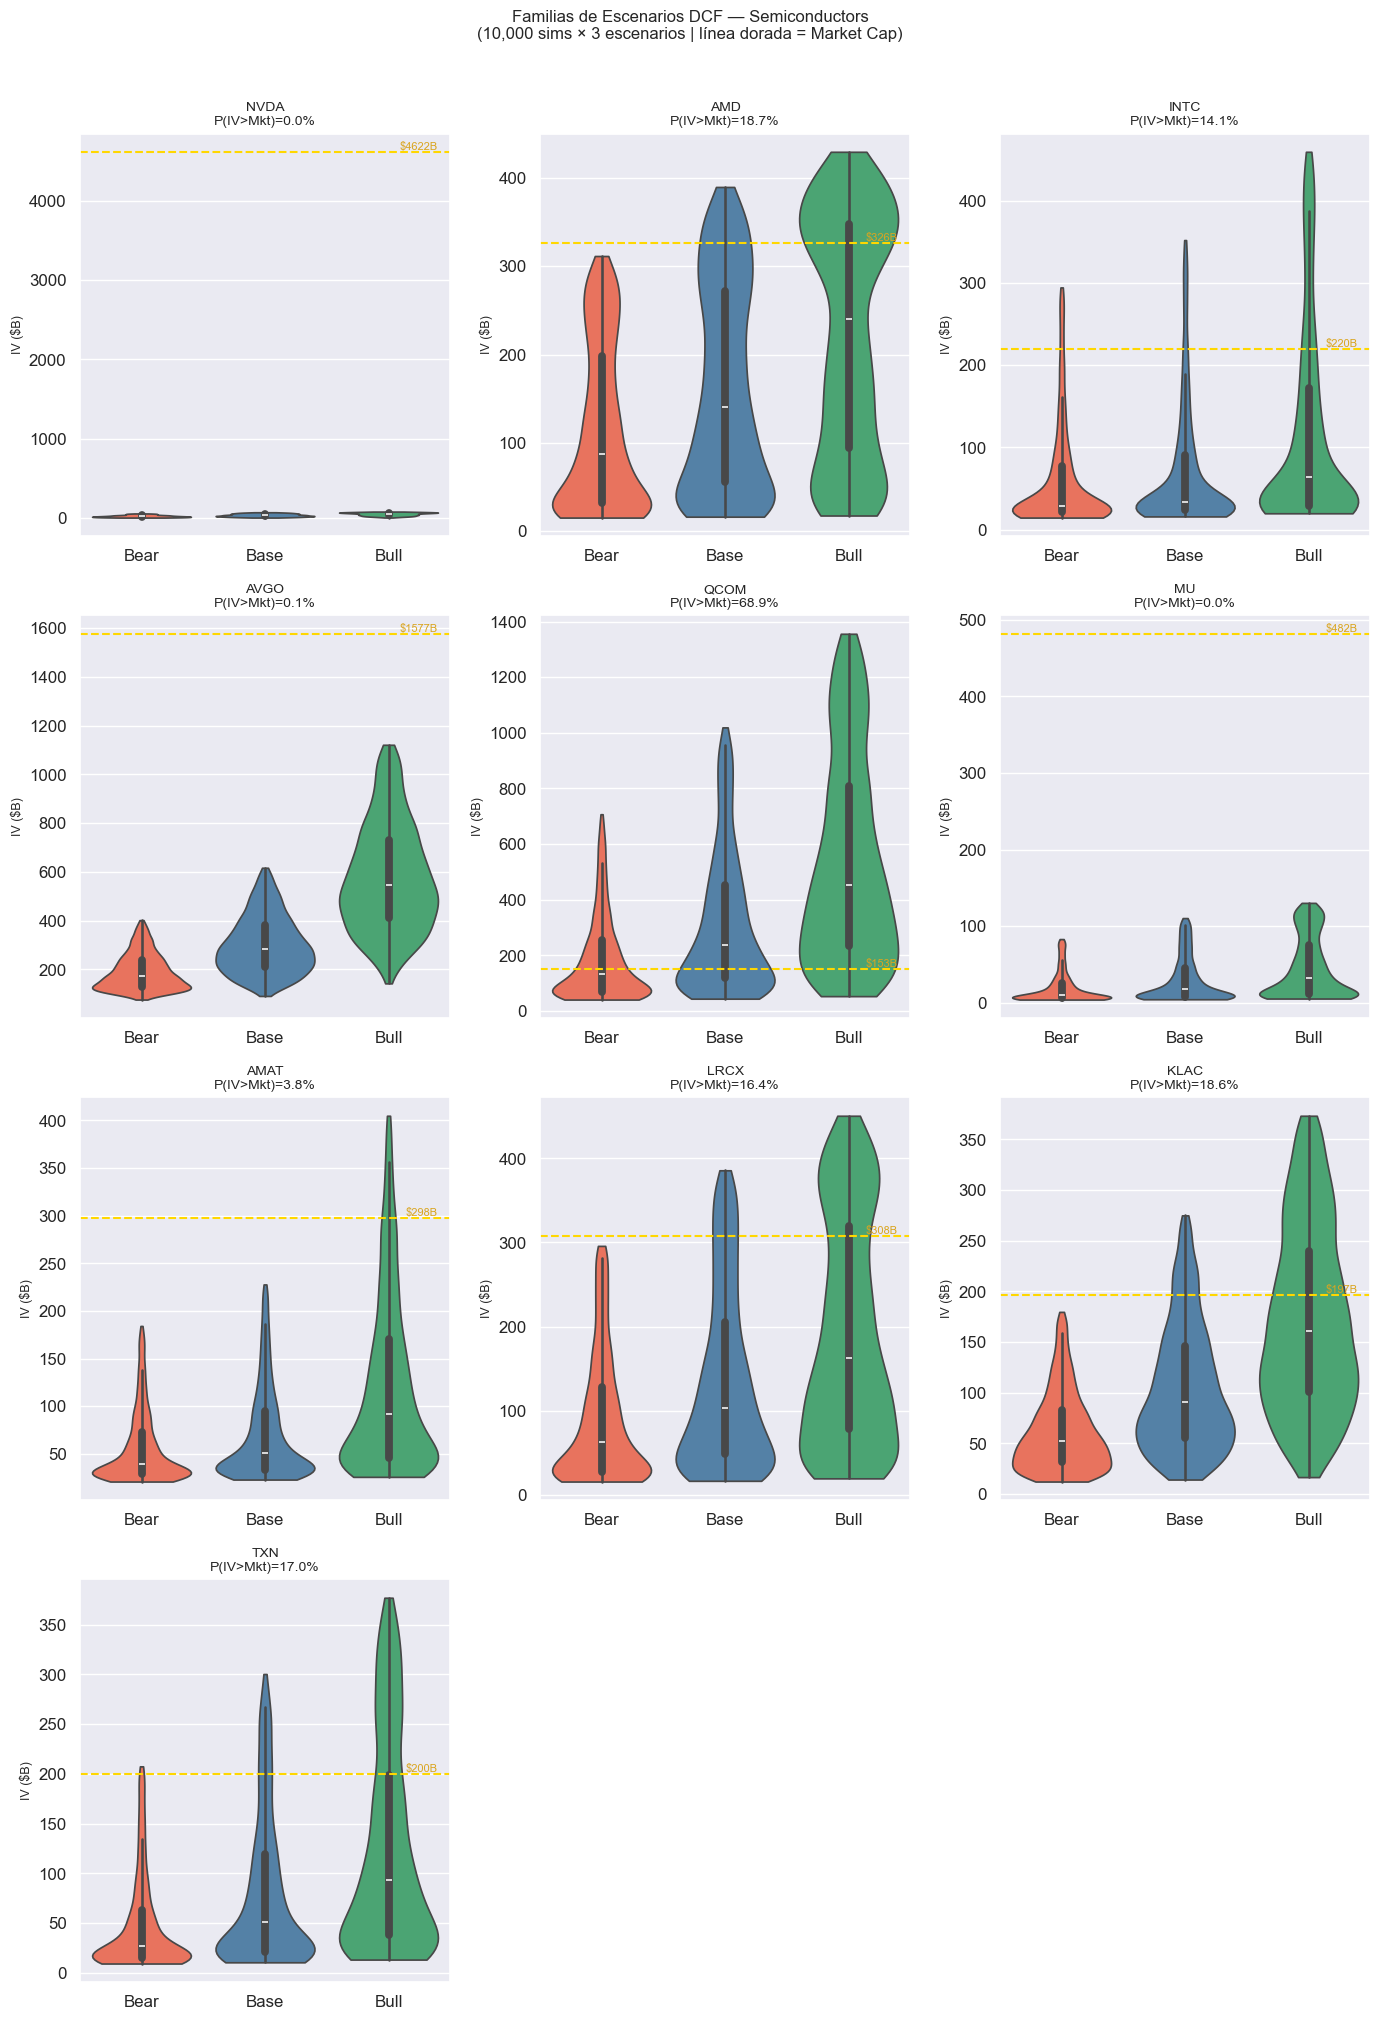

In [10]:
# ── 6.4 Familias de escenarios DCF — un subplot por empresa ──────────────────
# FIX: tamaño fijo por empresa para evitar gráfico larguísimo.
# Usamos un grid de filas × columnas en lugar de 1 × N.

tickers_ok = [
    t for t, r in dcf_results.items()
    if "error" not in r and "dist_bear" in r
]

n_cols = 3
n_rows = int(np.ceil(len(tickers_ok) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = np.array(axes).flatten()  # siempre array 1D

for i, ticker in enumerate(tickers_ok):
    ax  = axes[i]
    r   = dcf_results[ticker]
    mkt = r.get("market_cap_bn")

    # Construir DataFrame largo para seaborn
    # Limitar a 2000 puntos por escenario para que el violin sea manejable
    n_pts = 2000
    rows  = []
    for sc_name, dist_key in [("Bear", "dist_bear"), ("Base", "dist_base"), ("Bull", "dist_bull")]:
        dist = r[dist_key] / 1e9
        # Recortar outliers al P95 para que el eje sea legible
        p95  = np.percentile(dist, 95)
        dist = dist[dist <= p95]
        sample = np.random.choice(dist, size=min(n_pts, len(dist)), replace=False)
        for v in sample:
            rows.append({"Escenario": sc_name, "IV ($B)": v})

    df_viol = pd.DataFrame(rows)

    sns.violinplot(
        data=df_viol, x="Escenario", y="IV ($B)",
        palette={"Bear": "tomato", "Base": "steelblue", "Bull": "mediumseagreen"},
        inner="box", cut=0, ax=ax
    )

    if mkt:
        ax.axhline(mkt, color="gold", linewidth=1.5, linestyle="--")
        ax.text(2.4, mkt, f"${mkt:.0f}B", va="bottom", ha="right",
                fontsize=8, color="goldenrod")

    prob = r.get("prob_above_mktcap")
    title = f"{ticker}"
    if prob is not None:
        title += f"\nP(IV>Mkt)={prob:.1f}%"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("IV ($B)", fontsize=9)

# Ocultar ejes sobrantes si n_tickers no es múltiplo de n_cols
for j in range(len(tickers_ok), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Familias de Escenarios DCF — {SECTOR_NAME}\n"
             f"({N_SIMULATIONS:,} sims × 3 escenarios | línea dorada = Market Cap)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

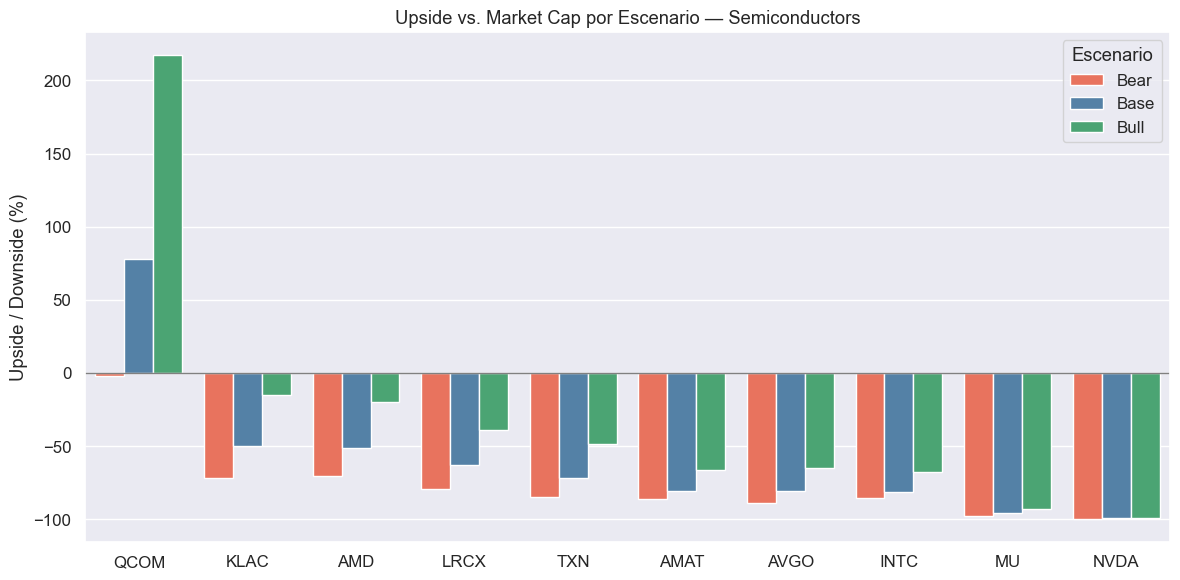

In [11]:
# ── 6.5 Upside por escenario ──────────────────────────────────────────────────
df_up = dcf_df.dropna(subset=["upside_bear_pct","upside_pct","upside_bull_pct"]).copy()
df_up = df_up.sort_values("upside_pct", ascending=False)

df_melt = df_up.melt(
    id_vars="ticker",
    value_vars=["upside_bear_pct","upside_pct","upside_bull_pct"],
    var_name="Escenario", value_name="Upside (%)"
)
df_melt["Escenario"] = df_melt["Escenario"].map({
    "upside_bear_pct": "Bear",
    "upside_pct":      "Base",
    "upside_bull_pct": "Bull",
})
df_melt["ticker"] = pd.Categorical(df_melt["ticker"], categories=df_up["ticker"].tolist(), ordered=True)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=df_melt, x="ticker", y="Upside (%)", hue="Escenario",
    palette={"Bear": "tomato", "Base": "steelblue", "Bull": "mediumseagreen"},
    ax=ax
)
ax.axhline(0, color="gray", linewidth=1)
ax.set_title(f"Upside vs. Market Cap por Escenario — {SECTOR_NAME}")
ax.set_xlabel("")
ax.set_ylabel("Upside / Downside (%)")
plt.tight_layout()
plt.show()

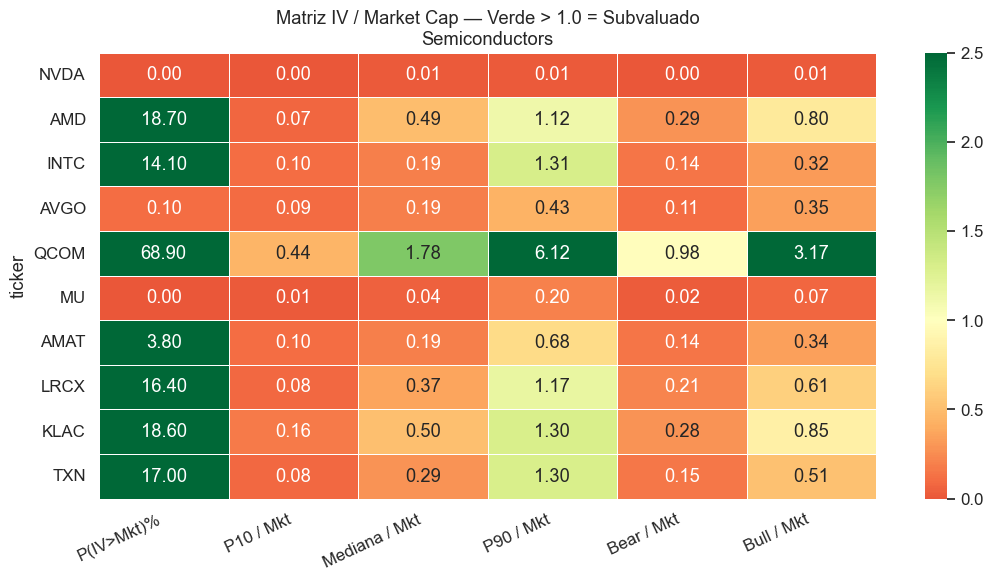

In [12]:
# ── 6.6 Matriz de valoración probabilística ───────────────────────────────────
df_mat = dcf_df.dropna(subset=["market_cap_bn","dcf_median_bn"]).copy()

mat_rows = []
for _, row in df_mat.iterrows():
    mkt = row["market_cap_bn"]
    r   = dcf_results.get(row["ticker"], {})
    if "dist_combined" not in r:
        continue
    dist = r["dist_combined"] / 1e9
    mat_rows.append({
        "ticker":           row["ticker"],
        "P(IV>Mkt)%":       round(float(np.mean(dist > mkt)) * 100, 1),
        "P10 / Mkt":        round(row["dcf_p10_bn"] / mkt, 2),
        "Mediana / Mkt":    round(row["dcf_median_bn"] / mkt, 2),
        "P90 / Mkt":        round(row["dcf_p90_bn"] / mkt, 2),
        "Bear / Mkt":       round(row["bear_median_bn"] / mkt, 2),
        "Bull / Mkt":       round(row["bull_median_bn"] / mkt, 2),
    })

mat_df = pd.DataFrame(mat_rows).set_index("ticker")

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    mat_df.astype(float), annot=True, fmt=".2f",
    cmap="RdYlGn", center=1.0, vmin=0, vmax=2.5,
    linewidths=0.4, ax=ax
)
ax.set_title(f"Matriz IV / Market Cap — Verde > 1.0 = Subvaluado\n{SECTOR_NAME}")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 7. Scorecard Final

In [13]:
def percentile_rank(series: pd.Series) -> pd.Series:
    return series.rank(pct=True) * 100


def build_scorecard(ratios_df: pd.DataFrame, dcf_df: pd.DataFrame) -> pd.DataFrame:
    """Scorecard ponderado en 3 dimensiones.
    
    - Calidad Fundamental (40%): ROE, ROA, Margen Neto
    - Solvencia y Riesgo (25%): D/E inverso, Current Ratio, Asset Turnover
    - Crecimiento y Valuación (35%): Revenue Growth, Upside Base DCF,
                                     P(IV>Mkt), FCF Growth Base
    """
    sc = ratios_df.copy()

    if not dcf_df.empty:
        cols = [c for c in ["ticker","upside_pct","prob_above_mktcap","base_growth_pct"] if c in dcf_df.columns]
        sc = sc.merge(dcf_df[cols], on="ticker", how="left")
    else:
        sc["upside_pct"] = sc["prob_above_mktcap"] = sc["base_growth_pct"] = np.nan

    # Calidad (40%)
    sc["s_roe"]    = percentile_rank(sc["roe_pct"].fillna(sc["roe_pct"].median()))
    sc["s_roa"]    = percentile_rank(sc["roa_pct"].fillna(sc["roa_pct"].median()))
    sc["s_margin"] = percentile_rank(sc["net_margin_pct"].fillna(sc["net_margin_pct"].median()))
    quality = sc["s_roe"] * 0.40 + sc["s_roa"] * 0.30 + sc["s_margin"] * 0.30

    # Solvencia (25%)
    sc["s_de"] = 100 - percentile_rank(sc["debt_to_equity"].fillna(sc["debt_to_equity"].median()))
    sc["s_cr"] = percentile_rank(sc["current_ratio"].fillna(sc["current_ratio"].median()))
    sc["s_at"] = percentile_rank(sc["asset_turnover"].fillna(sc["asset_turnover"].median()))
    solvency = sc["s_de"] * 0.40 + sc["s_cr"] * 0.35 + sc["s_at"] * 0.25

    # Crecimiento + Valuación (35%)
    sc["s_rev"]    = percentile_rank(sc["revenue_growth_pct"].fillna(0))
    sc["s_upside"] = percentile_rank(sc["upside_pct"].fillna(0))
    sc["s_prob"]   = percentile_rank(sc["prob_above_mktcap"].fillna(0))
    sc["s_fcfg"]   = percentile_rank(sc["base_growth_pct"].fillna(0))
    growth = sc["s_rev"] * 0.25 + sc["s_upside"] * 0.35 + sc["s_prob"] * 0.25 + sc["s_fcfg"] * 0.15

    sc["score_quality"]   = quality.round(1)
    sc["score_solvency"]  = solvency.round(1)
    sc["score_growth"]    = growth.round(1)
    sc["composite_score"] = (quality * 0.40 + solvency * 0.25 + growth * 0.35).round(1)

    sc["rating"] = sc["composite_score"].apply(
        lambda s: "OVERWEIGHT" if s >= 65 else "NEUTRAL" if s >= 35 else "UNDERWEIGHT"
    )
    sc = sc.sort_values("composite_score", ascending=False).reset_index(drop=True)
    sc["rank"] = range(1, len(sc) + 1)
    return sc


scorecard = build_scorecard(latest_year_df, dcf_df)

scorecard[[
    "rank","ticker","composite_score","score_quality",
    "score_solvency","score_growth","rating",
    "net_margin_pct","roe_pct","upside_pct","prob_above_mktcap"
]].rename(columns={
    "composite_score": "Score", "score_quality": "Calidad",
    "score_solvency": "Solvencia", "score_growth": "Crec.",
    "net_margin_pct": "Margen%", "roe_pct": "ROE%",
    "upside_pct": "Upside%", "prob_above_mktcap": "P(IV>Mkt)%"
}).round(1)

,rank,ticker,Score,Calidad,Solvencia,Crec.,rating,Margen%,ROE%,Upside%,P(IV>Mkt)%
0,1,NVDA,80.5,100.0,96.0,47.2,OVERWEIGHT,55.8,91.9,-99.3,0.0
1,2,KLAC,70.5,86.0,34.5,78.5,OVERWEIGHT,33.4,86.6,-49.9,18.6
2,3,TXN,69.3,76.0,77.2,56.0,OVERWEIGHT,28.3,30.7,-71.5,17.0
3,4,QCOM,62.4,58.5,41.8,81.5,NEUTRAL,12.5,89.3,78.0,68.9
4,5,LRCX,60.1,55.0,51.0,72.5,NEUTRAL,NaN,NaN,-63.1,16.4
5,6,AMD,54.8,30.0,53.5,84.0,NEUTRAL,12.5,6.9,-51.4,18.7
6,7,MU,46.7,55.0,51.0,34.2,NEUTRAL,NaN,NaN,-95.9,0.0
7,8,AVGO,42.7,45.5,51.0,33.5,NEUTRAL,20.5,4.2,-80.6,0.1
8,9,AMAT,32.0,34.0,27.5,33.0,UNDERWEIGHT,18.6,8.5,-80.5,3.8
9,10,INTC,21.0,10.0,26.5,29.5,UNDERWEIGHT,-0.5,-0.2,-81.1,14.1


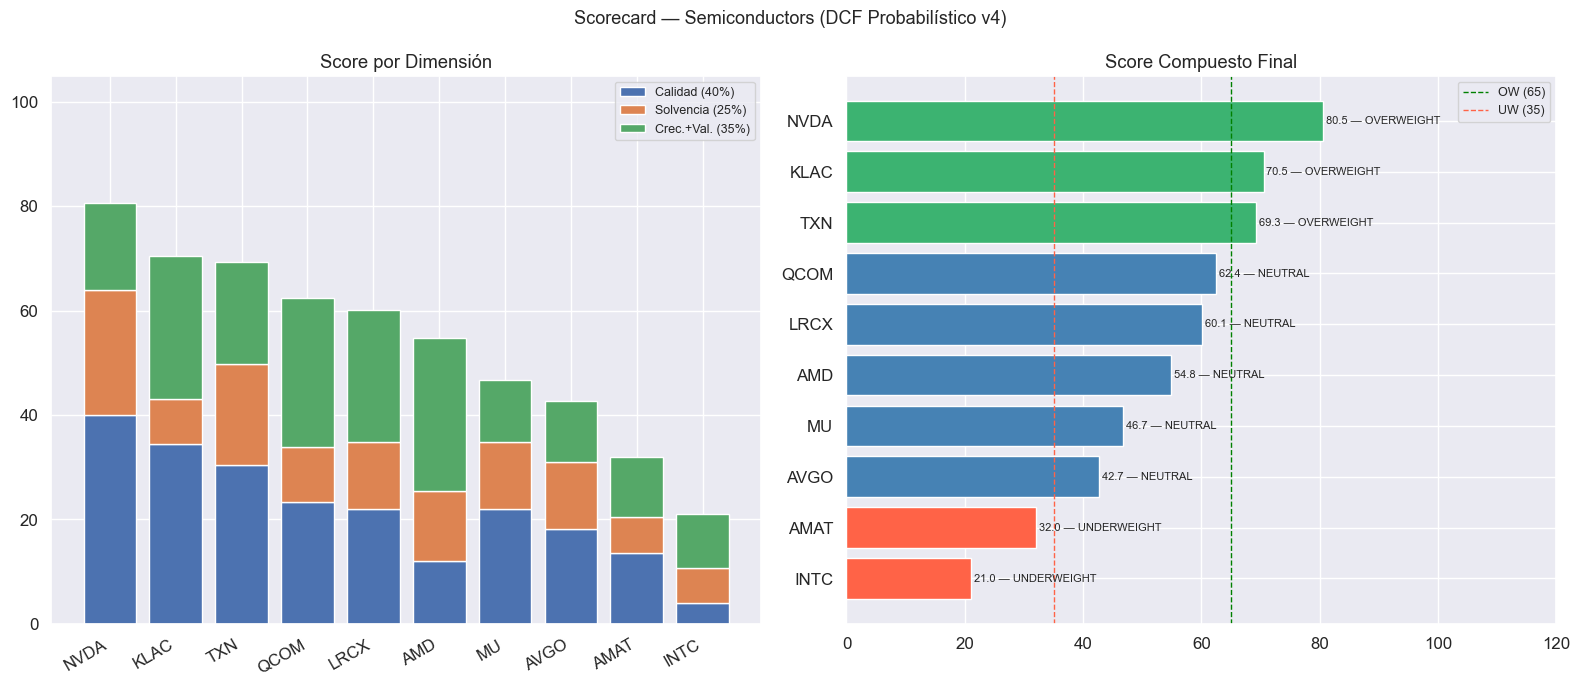

In [14]:
# ── Scorecard: stacked bar + horizontal bar ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel izquierdo: stacked bar por dimensión
ax1  = axes[0]
x    = np.arange(len(scorecard))
q    = (scorecard["score_quality"]  * 0.40).values
s    = (scorecard["score_solvency"] * 0.25).values
g    = (scorecard["score_growth"]   * 0.35).values
ax1.bar(x, q, label="Calidad (40%)")
ax1.bar(x, s, bottom=q, label="Solvencia (25%)")
ax1.bar(x, g, bottom=q+s, label="Crec.+Val. (35%)")
ax1.set_xticks(x)
ax1.set_xticklabels(scorecard["ticker"], rotation=30, ha="right")
ax1.set_title("Score por Dimensión")
ax1.set_ylim(0, 105)
ax1.legend(fontsize=9)

# Panel derecho: score compuesto horizontal
ax2   = axes[1]
df_s  = scorecard.sort_values("composite_score", ascending=True)
palette = {"OVERWEIGHT": "mediumseagreen", "NEUTRAL": "steelblue", "UNDERWEIGHT": "tomato"}
colors  = [palette[r] for r in df_s["rating"]]
ax2.barh(df_s["ticker"], df_s["composite_score"], color=colors)
ax2.axvline(65, color="green",  linestyle="--", linewidth=1, label="OW (65)")
ax2.axvline(35, color="tomato", linestyle="--", linewidth=1, label="UW (35)")
for i, (_, row) in enumerate(df_s.iterrows()):
    ax2.text(row["composite_score"] + 0.5, i,
             f"{row['composite_score']:.1f} — {row['rating']}",
             va="center", fontsize=8)
ax2.set_xlim(0, 120)
ax2.set_title("Score Compuesto Final")
ax2.legend(fontsize=9)

fig.suptitle(f"Scorecard — {SECTOR_NAME} (DCF Probabilístico v4)", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Resumen Ejecutivo

In [15]:
print("=" * 80)
print(f"  RESUMEN EJECUTIVO — {SECTOR_NAME.upper()} (DCF PROBABILÍSTICO)")
print("=" * 80)

for rating, group in scorecard.groupby("rating", sort=False):
    icon = {"OVERWEIGHT": "✅", "NEUTRAL": "➖", "UNDERWEIGHT": "⚠️"}.get(rating, "")
    print(f"\n{icon} {rating}:")
    for _, row in group.sort_values("composite_score", ascending=False).iterrows():
        prob   = row.get("prob_above_mktcap", float("nan"))
        upside = row.get("upside_pct",        float("nan"))
        print(f"   {row['ticker']:6s} | Score: {row['composite_score']:.1f} "
              f"| Upside Base: {upside:.1f}% | P(IV>Mkt): {prob:.1f}%")

print("\n" + "─" * 80)
print("  DCF PROBABILÍSTICO — RESUMEN:")
print(f"  {'Ticker':8s} {'FCFnorm':>9s} {'Growth%':>8s} {'WACC%':>7s} "
      f"{'Bear':>8s} {'Base':>8s} {'Bull':>8s} {'Mkt':>7s} {'P(IV>Mkt)':>10s}")
for _, row in dcf_df.sort_values("prob_above_mktcap", ascending=False).iterrows():
    print(f"  {row['ticker']:8s} "
          f"${row['normalized_fcf_bn']:>7.1f}B "
          f"{row['base_growth_pct']:>7.1f}% "
          f"{row['wacc_base_pct']:>6.1f}% "
          f"${row['bear_median_bn']:>5.0f}B "
          f"${row['base_median_bn']:>5.0f}B "
          f"${row['bull_median_bn']:>5.0f}B "
          f"${row.get('market_cap_bn',0) or 0:>5.0f}B "
          f"{row.get('prob_above_mktcap',0) or 0:>9.1f}%")

print("\n" + "=" * 80)
print("  ⚠️  Solo fines educativos. No constituye asesoría de inversión.")
print("=" * 80)

  RESUMEN EJECUTIVO — SEMICONDUCTORS (DCF PROBABILÍSTICO)

✅ OVERWEIGHT:
   NVDA   | Score: 80.5 | Upside Base: -99.3% | P(IV>Mkt): 0.0%
   KLAC   | Score: 70.5 | Upside Base: -49.9% | P(IV>Mkt): 18.6%
   TXN    | Score: 69.3 | Upside Base: -71.5% | P(IV>Mkt): 17.0%

➖ NEUTRAL:
   QCOM   | Score: 62.4 | Upside Base: 78.0% | P(IV>Mkt): 68.9%
   LRCX   | Score: 60.1 | Upside Base: -63.1% | P(IV>Mkt): 16.4%
   AMD    | Score: 54.8 | Upside Base: -51.4% | P(IV>Mkt): 18.7%
   MU     | Score: 46.7 | Upside Base: -95.9% | P(IV>Mkt): 0.0%
   AVGO   | Score: 42.7 | Upside Base: -80.6% | P(IV>Mkt): 0.1%

⚠️ UNDERWEIGHT:
   AMAT   | Score: 32.0 | Upside Base: -80.5% | P(IV>Mkt): 3.8%
   INTC   | Score: 21.0 | Upside Base: -81.1% | P(IV>Mkt): 14.1%

────────────────────────────────────────────────────────────────────────────────
  DCF PROBABILÍSTICO — RESUMEN:
  Ticker     FCFnorm  Growth%   WACC%     Bear     Base     Bull     Mkt  P(IV>Mkt)
  QCOM     $   10.8B    18.9%   10.5% $  150B $  266B $

## 9. Exportación CSV y SQLite

In [16]:
import os, sqlite3
from sqlite3 import Error

os.makedirs("./output", exist_ok=True)
sector_df.to_csv(f"./output/historical_ratios_{SECTOR_NAME.lower()}.csv",  index=False)
dcf_df.to_csv(   f"./output/dcf_probabilistic_{SECTOR_NAME.lower()}.csv",  index=False)
scorecard.to_csv(f"./output/scorecard_{SECTOR_NAME.lower()}.csv",          index=False)
print("✅ CSVs exportados a ./output/")


def create_connection(db_file):
    conn = None
    try:
        conn = sqlite3.connect(db_file)
        print(f"✅ Conexión: {db_file}")
    except Error as e:
        print(f"❌ {e}")
    return conn


def save_to_sqlite(conn, df, table_name):
    """Guarda DataFrame en SQLite excluyendo columnas con arrays numpy."""
    try:
        df_clean = df.select_dtypes(exclude=["object"]).copy()
        str_cols = [c for c in df.columns
                    if df[c].dtype == object
                    and df[c].apply(lambda x: isinstance(x, str) or pd.isna(x)).all()]
        df_clean = pd.concat([df[str_cols], df_clean], axis=1)
        df_clean.to_sql(table_name, conn, if_exists="replace", index=False)
        n = pd.read_sql(f"SELECT COUNT(*) as n FROM {table_name}", conn).iloc[0, 0]
        print(f"  ✓ '{table_name}' — {n} filas")
    except Error as e:
        print(f"  ❌ {table_name}: {e}")


DB_FILE = f"{SECTOR_NAME.lower()}_analysis.db"
conn    = create_connection(DB_FILE)

if conn:
    save_to_sqlite(conn, sector_df,      "sector_ratios")
    save_to_sqlite(conn, latest_year_df, "latest_year_ratios")
    save_to_sqlite(conn, dcf_df,         "dcf_probabilistic")
    save_to_sqlite(conn, scorecard,      "scorecard")

    print("\n📊 Top por P(IV > Market Cap):")
    q = pd.read_sql("""
        SELECT ticker,
               ROUND(prob_above_mktcap,1)  AS prob_pct,
               ROUND(base_median_bn,0)     AS iv_base_bn,
               ROUND(market_cap_bn,0)      AS mkt_bn,
               ROUND(upside_pct,1)         AS upside,
               ROUND(base_growth_pct,1)    AS growth_pct,
               ROUND(wacc_base_pct,1)      AS wacc_pct
        FROM   dcf_probabilistic
        ORDER  BY prob_above_mktcap DESC
    """, conn)
    print(q.to_string(index=False))

    conn.close()
    print(f"\n✅ DB guardada: {DB_FILE}")

✅ CSVs exportados a ./output/
✅ Conexión: semiconductors_analysis.db
  ✓ 'sector_ratios' — 55 filas
  ✓ 'latest_year_ratios' — 10 filas
  ✓ 'dcf_probabilistic' — 10 filas
  ✓ 'scorecard' — 10 filas

📊 Top por P(IV > Market Cap):
ticker  prob_pct  iv_base_bn  mkt_bn  upside  growth_pct  wacc_pct
  QCOM      68.9       266.0   153.0    78.0        18.9      10.5
   AMD      18.7       156.0   326.0   -51.4        36.8      13.0
  KLAC      18.6        96.0   197.0   -49.9        25.2      11.3
   TXN      17.0        56.0   200.0   -71.5        13.2       9.7
  LRCX      16.4       108.0   308.0   -63.1        23.9      12.4
  INTC      14.1        38.0   220.0   -81.1        -5.0      11.0
  AMAT       3.8        53.0   298.0   -80.5        -2.7      12.1
  AVGO       0.1       297.0  1577.0   -80.6         3.0      10.5
  NVDA       0.0        34.0  4622.0   -99.3        40.0      14.3
    MU       0.0        19.0   482.0   -95.9        11.3      11.5

✅ DB guardada: semiconductors_ana